<a href="https://colab.research.google.com/github/mikysetiawan/FundamentalDeepL/blob/master/Tugas_2_ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf /content/hurricane_data/dataset/
!rm -rf /content/Dataset-Final/

In [2]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [4]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [6]:
# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.20.0


In [7]:
# Import module yang disediakan google colab untuk kebutuhan upload file

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mikysetiawan","key":"d9a7e7ada6814b9eff0d854f1f66b57f"}'}

# Data Preparation

---



In [8]:
# Download kaggle dataset and unzip the file
# !cp kaggle.json ~/.kaggle/

# !chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d kmader/satellite-images-of-hurricane-damage
!unzip satellite-images-of-hurricane-damage.zip -d hurricane_data

Streaming output truncated to the last 5000 lines.
  inflating: hurricane_data/train_another/no_damage/-95.627453_29.859303000000004.jpeg  
  inflating: hurricane_data/train_another/no_damage/-95.62745600000001_29.777524.jpeg  
  inflating: hurricane_data/train_another/no_damage/-95.627485_29.777865999999996.jpeg  
  inflating: hurricane_data/train_another/no_damage/-95.62751800000001_29.857785999999997.jpeg  
  inflating: hurricane_data/train_another/no_damage/-95.62751999999999_29.860796999999998.jpeg  
  inflating: hurricane_data/train_another/no_damage/-95.627523_29.770004999999998.jpeg  
  inflating: hurricane_data/train_another/no_damage/-95.62753000000001_29.863289.jpeg  
  inflating: hurricane_data/train_another/no_damage/-95.627539_29.827047999999998.jpeg  
  inflating: hurricane_data/train_another/no_damage/-95.627543_29.860021000000003.jpeg  
  inflating: hurricane_data/train_another/no_damage/-95.627563_29.8628.jpeg  
  inflating: hurricane_data/train_another/no_damage/-95.

In [9]:
# Direktori awal untuk train dan test
train_dir = "hurricane_data/train_another"
val_dir = "hurricane_data/validation_another"
test_dir = "hurricane_data/test_another"

# Direktori baru untuk dataset gabungan
combined_dir = "hurricane_data/dataset"

In [10]:
# Buat direktori baru untuk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

In [11]:
# Salin file dan folder dari train
for category in os.listdir(train_dir):
    category_dir = os.path.join(train_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari validation
for category in os.listdir(val_dir):
    category_dir = os.path.join(val_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari test
for category in os.listdir(test_dir):
    category_dir = os.path.join(test_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

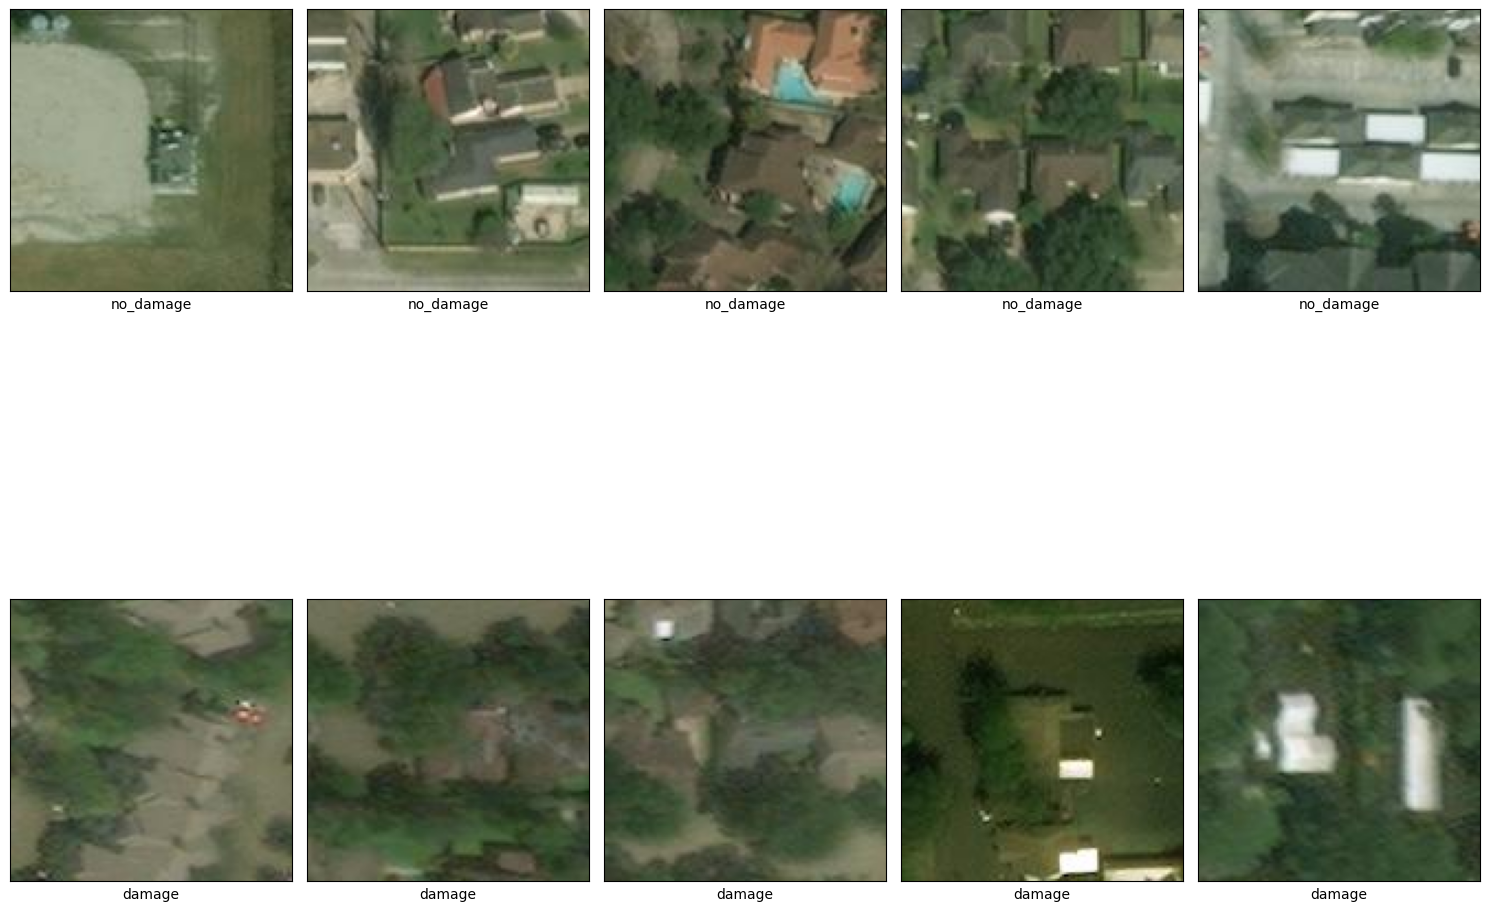

In [12]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
disaster_image = {}

# Tentukan path sumber train
path = "hurricane_data/"
path_sub = os.path.join(path, "dataset")
for i in os.listdir(path_sub):
    disaster_image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap dari 2 kelas dari data.
# Anda akan melihat gambar yang berbeda setiap kali kode ini dijalankan.
path_sub = "hurricane_data/dataset/"

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(disaster_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(disaster_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("RGB")
        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

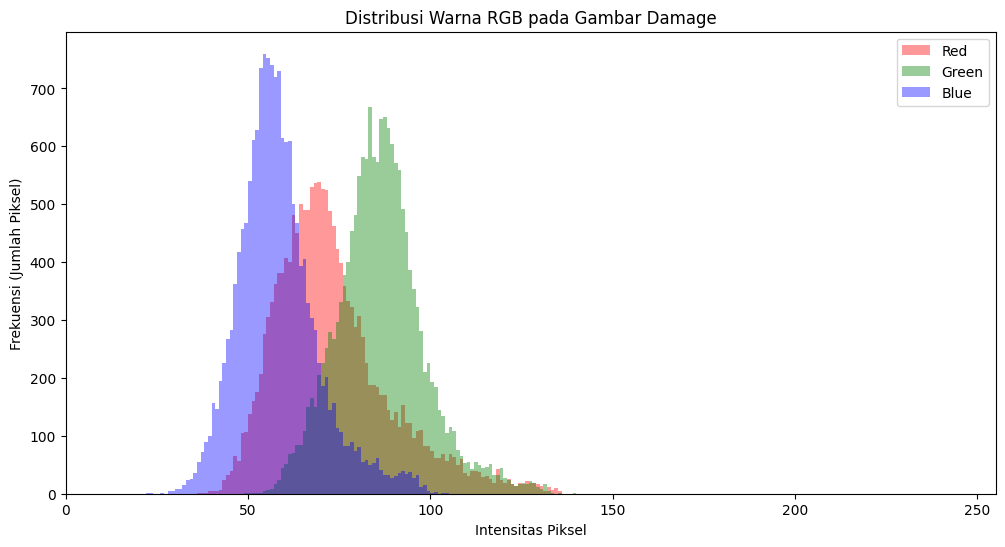

In [13]:
# Tampilkan distribusi warna historigram

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 1. Ambil sampel gambar
sample_path = os.path.join(path_sub, "damage", disaster_image["damage"][0])
img = np.array(Image.open(sample_path).convert("RGB")) # Pastikan RGB

jpg_channels = ['Red', 'Green', 'Blue']
jpg_channel_colors = ['r', 'g', 'b'] # Urutan disesuaikan dengan RGB

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(len(jpg_channels)):
    # Menggunakan flatten() untuk mengubah matrix 2D menjadi 1D array
    ax.hist(img[:,:,i].flatten(), bins=np.arange(256),
            label=jpg_channels[i], color=jpg_channel_colors[i], alpha=0.4)

ax.legend()
ax.set_title("Distribusi Warna RGB pada Gambar Damage")
ax.set_xlim(0, 255)
ax.set_xlabel("Intensitas Piksel")
ax.set_ylabel("Frekuensi (Jumlah Piksel)")

plt.show()

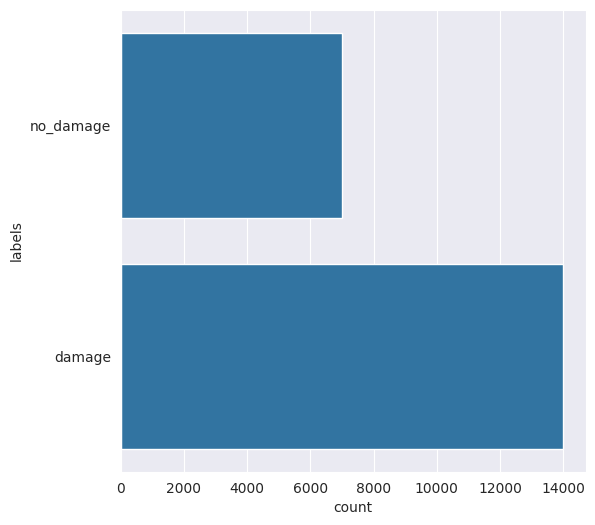

In [14]:
# Definisikan path sumber
disaster_path = "hurricane_data/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(disaster_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

# Data Augmentation

---



In [15]:
# Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    sudut = random.randint(0,180)
    return rotate(img, sudut)

# Membuat fungsi untuk melakukan rotasi searah jarum jam
def clockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    sudut = random.randint(0,180)
    return rotate(img, -sudut)

# Membuat fungsi untuk membalik gambar secara vertikal dari atas ke bawah
def flip_up_down(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    return np.flipud(img)

# Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    img = adjust_gamma(img, gamma=0.5,gain=1)
    return img

# Membuat fungsi untuk memberikan efek blur pada gambar
def blur_image(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    return cv2.GaussianBlur(img, (9,9),0)

# Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(shear=0.2)
    shear_image = warp(img, transform, mode="wrap")
    return shear_image

# Membuat fungsi untuk melakukan pergeseran melengkung pada gambar
def warp_shift(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(translation=(0,40))
    warp_image = warp(img, transform, mode="wrap")
    return warp_image

In [16]:
# Membuat variabel transformasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'warp shift': warp_shift,
                    'blurring image': blur_image,
                    'add brightness' : add_brightness,
                    'flip up down': flip_up_down,
                    'shear image': sheared
                  }

images_path="hurricane_data/dataset/no_damage" # Path untuk gambar asli
images=[] # Penyimpanan gambar yang telah melalui pra-pemrosesan

# Baca nama gambar dari folder dan tambahkan path ke dalam array "images"
for im in os.listdir(images_path):
    images.append(os.path.join(images_path,im))

# Jumlah gambar yang akan ditambahkan dengan hasil transformasi augmentasi, jumlahnya disesuaikan sesuai kebutuhan
# Variabel untuk melakukan iterasi sampai jumlah gambar yang ditentukan dalam images_to_generate
images_to_generate=7000
i=1

while i<=images_to_generate:
    image=random.choice(images)
    try:
        original_image = io.imread(image)
        transformed_image=None
        n = 0      # Variabel untuk melakukan iterasi sampai jumlah transformasi yang akan diterapkan
        transformation_count = random.randint(1, len(transformations)) # Pilih jumlah transformasi acak yang akan diterapkan pada gambar

        while n <= transformation_count:
            key = random.choice(list(transformations)) # Secara acak memilih dan memanggil metode
            transformed_image = transformations[key](original_image)
            n = n + 1

        new_image_path= "%s/augmented_image_%s.jpg" %(images_path, i)
        transformed_image = img_as_ubyte(transformed_image)  # Mengonversi gambar ke format byte yang tidak ditandatangani, dengan nilai dalam [0, 255]
        cv2.imwrite(new_image_path, transformed_image)  # Simpan hasil transformasi augmentasi pada gambar ke path yang ditentukan
        i =i+1
    except ValueError as e:
        print('could not read the',image ,':',e,'hence skipping it.')

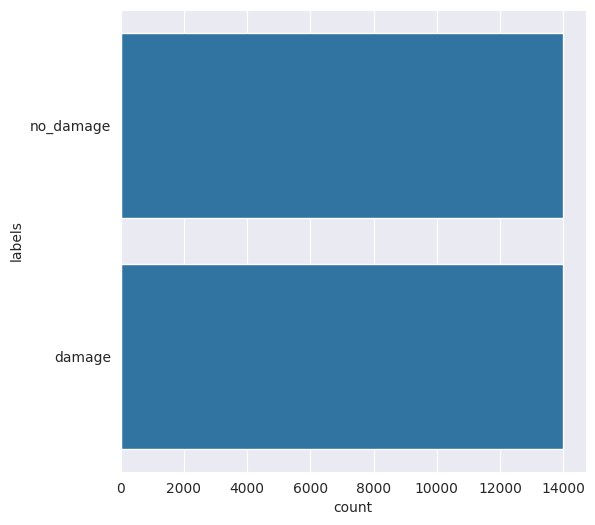

In [17]:
# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(disaster_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})
distribution_train['labels'] = distribution_train['labels'].str.replace('_augmented', '')

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

# Data Splitting

---



In [18]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= 'hurricane_data/dataset/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})

# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
damage,14000
no_damage,14000


In [19]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels

X= df['path']
y= df['labels']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

In [20]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [21]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "hurricane_data/dataset/"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"


set    labels   
test   damage        2817
       no_damage     2783
train  damage       11183
       no_damage    11217
dtype: int64 


                                                    path     labels    set
9114   hurricane_data/dataset/damage/-95.642602_29.83...     damage  train
1647   hurricane_data/dataset/damage/-95.079214000000...     damage  train
24800  hurricane_data/dataset/no_damage/-95.631932999...  no_damage   test
1519   hurricane_data/dataset/damage/-95.123604_29.96...     damage  train
5441   hurricane_data/dataset/no_damage/augmented_ima...  no_damage  train


In [22]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']

    # Cek apakah file benar-benar ada di path tersebut
    if not os.path.exists(file_path):
        print(f"File tidak ditemukan: {file_path}")
        continue # Lewati jika file tidak ada

    # Buat direktori tujuan (menggunakan label yang sudah bersih/tanpa '_augmented')
    dest_dir = os.path.join(dataset_path, row['set'], row['labels'])
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    # Tentukan tujuan file
    destination_file_name = os.path.basename(file_path)
    file_dest = os.path.join(dest_dir, destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

# Image Data Generator

---



In [23]:
# Definisikan direktori training dan test
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"

train_no_damage = os.path.join(TRAIN_DIR + '/no_damage')
train_damage = os.path.join(TRAIN_DIR + '/damage')
test_no_damage = os.path.join(TEST_DIR + '/no_damage')
test_damage = os.path.join(TEST_DIR + '/damage')

print("Total number of no_damage images in training set: ",len(os.listdir(train_no_damage)))
print("Total number of damage images in training set: ",len(os.listdir(train_damage)))
print("Total number of no_damage images in test set: ",len(os.listdir(test_no_damage)))
print("Total number of damage images in test set: ",len(os.listdir(test_damage)))

Total number of no_damage images in training set:  11217
Total number of damage images in training set:  11183
Total number of no_damage images in test set:  2783
Total number of damage images in test set:  2817


In [24]:
# Buat objek ImageDataGenerator yang menormalkan gambar
# Menggunakan preprocess_input bawaan DenseNet
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    # Tambahkan sedikit augmentasi di sini agar model lebih tangguh
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Training Generator
train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=32,
    target_size=(128, 128), # Sesuaikan dengan input_shape model
    color_mode="rgb",       # WAJIB RGB untuk DenseNet121
    class_mode='binary',
    subset='training',
    shuffle=True
)

# Validation Generator
validation_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=32,
    target_size=(128, 128),
    color_mode="rgb",
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# Test Generator
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    batch_size=1,
    target_size=(128, 128),
    color_mode="rgb",
    class_mode='binary',
    shuffle=False
)

Found 17921 images belonging to 2 classes.
Found 4479 images belonging to 2 classes.
Found 5600 images belonging to 2 classes.


# DenseNet121

---



In [25]:
# 1. Inisialisasi DenseNet121 sebagai 'mata' pendeteksi fitur
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

# 2. Membangun Model Sequential sesuai Kriteria 4
model_final = models.Sequential([
    # Memasukkan base_model (kumpulan Conv2D & Pooling) ke dalam urutan pertama
    base_model,

    # Menambahkan GlobalAveragePooling2D (Pooling Layer)
    layers.GlobalAveragePooling2D(),

    # Fully Connected Layer untuk klasifikasi
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# 3. Compile Model
model_final.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model_final.summary())

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

None


In [26]:
# Tambahkan Callbacks agar training lebih pintar
callbacks = [
    # Berhenti otomatis jika akurasi tidak naik lagi (mencegah overfitting)
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    # Menurunkan learning rate jika progres melambat
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

# Mulai Training
history = model_final.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=callbacks
)

Epoch 1/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 172s 261ms/step - accuracy: 0.9175 - loss: 0.2080 - val_accuracy: 0.8674 - val_loss: 0.3112 - learning_rate: 0.0010
Epoch 2/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 112s 200ms/step - accuracy: 0.9484 - loss: 0.1303 - val_accuracy: 0.8602 - val_loss: 0.3260 - learning_rate: 0.0010
Epoch 3/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 111s 198ms/step - accuracy: 0.9583 - loss: 0.1062 - val_accuracy: 0.8357 - val_loss: 0.3502 - learning_rate: 0.0010
Epoch 4/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 111s 197ms/step - accuracy: 0.9622 - loss: 0.0913 - val_accuracy: 0.8547 - val_loss: 0.3408 - learning_rate: 0.0010
Epoch 5/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 111s 197ms/step - accuracy: 0.9715 - loss: 0.0732 - val_accuracy: 0.8692 - val_loss: 0.2941 - learning_rate: 2.0000e-04
Epoch 6/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 110s 196ms/step - accuracy: 0.9730 - loss: 0.0667 - val_accuracy: 0.8832 - val_loss: 0.2819 - learning_rate: 2.0000e-04
Epoch 7/20
561/561 ━━━━━━━━━━━━━━━━━━━━ 108s 193ms/step 

In [27]:
print(history)

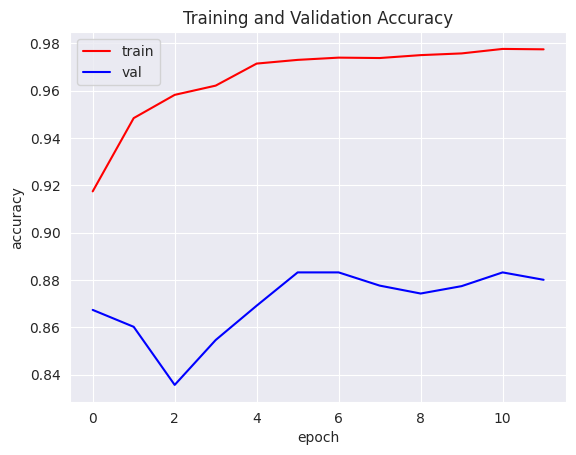

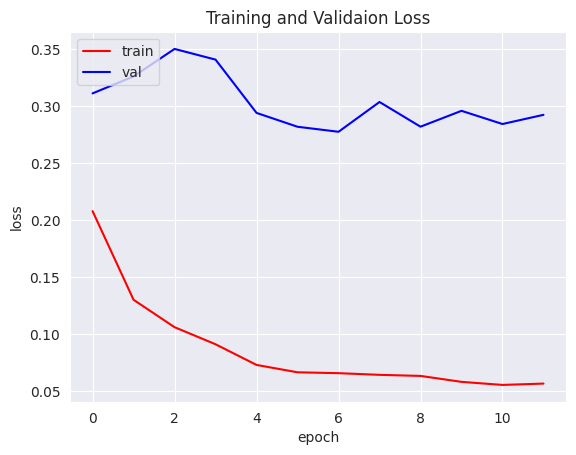

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [1]:
test_generator.reset()

preds_1 = model_final.predict(test_generator,verbose=0)
preds_1 = preds_1.copy()
preds_1[preds_1 <= 0.5] = 0
preds_1[preds_1 > 0.5] = 1

# Print Confusion Matrix
cm = pd.DataFrame(data=confusion_matrix(test_generator.classes, preds_1, labels=[0, 1]),index=["Actual No Damage", "Actual Damage"],
columns=["Predicted No Damage", "Predicted Damage"])
sns.heatmap(cm,annot=True,fmt="d")

# Print Classification Report
print("\n")
print(classification_report(y_true=test_generator.classes,y_pred=preds_1,target_names =['No Damage','Damage'], digits=4))

NameError: name 'test_generator' is not defined

# Export Model

---



In [ ]:
import tensorflow as tf
import os

# Tentukan direktori penyimpanan
export_dir = 'saved_model/'
tf.saved_model.save(model_final, export_dir)

print("Model berhasil disimpan dalam format SavedModel di folder:", export_dir)